## 线性插值

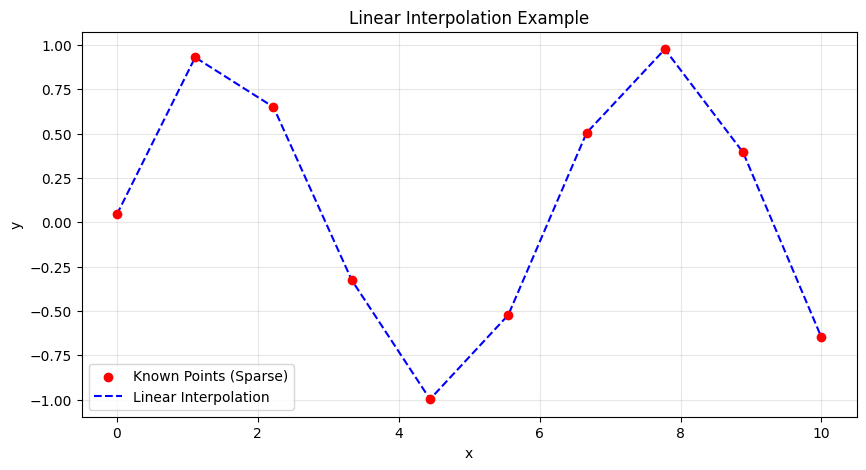

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成原始的稀疏数据点 (已知点)
x_known = np.linspace(0, 10, num=10)           # 在 0 到 10 之间取 10 个点
y_known = np.sin(x_known) + np.random.normal(0, 0.1, size=10) # 正弦函数 + 随机噪声

# 2. 定义想要插值的密集坐标 (目标点)
x_interp = np.linspace(0, 10, num=100)         # 在同样范围内取 100 个点，让曲线看起来更平滑

# 3. 执行线性插值
# np.interp(目标x, 已知x, 已知y)
y_interp = np.interp(x_interp, x_known, y_known)

# 4. 可视化结果
plt.figure(figsize=(10, 5))
plt.scatter(x_known, y_known, color='red', label='Known Points (Sparse)', zorder=5)
plt.plot(x_interp, y_interp, '--', color='blue', label='Linear Interpolation')
plt.title('Linear Interpolation Example')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 二次插值

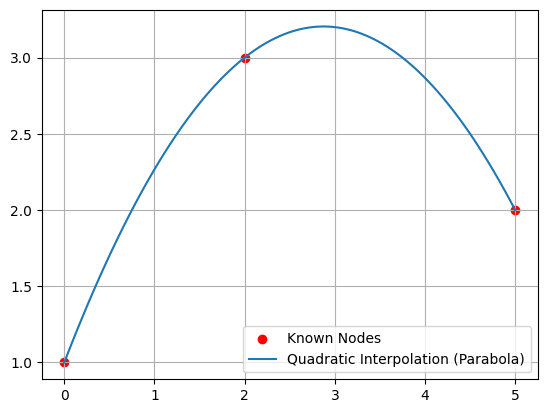

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. 定义 3 个已知点
x_nodes = np.array([0, 2, 5])
y_nodes = np.array([1, 3, 2])

# 2. 使用 scipy 创建二次插值函数
f_quad = interp1d(x_nodes, y_nodes, kind='quadratic')

# 3. 生成密集的插值点用于绘图
x_new = np.linspace(0, 5, 100)
y_new = f_quad(x_new)

# 4. 绘图对比
plt.scatter(x_nodes, y_nodes, color='red', label='Known Nodes')
plt.plot(x_new, y_new, label='Quadratic Interpolation (Parabola)')
plt.legend()
plt.grid(True)
plt.show()

## 龙格现象

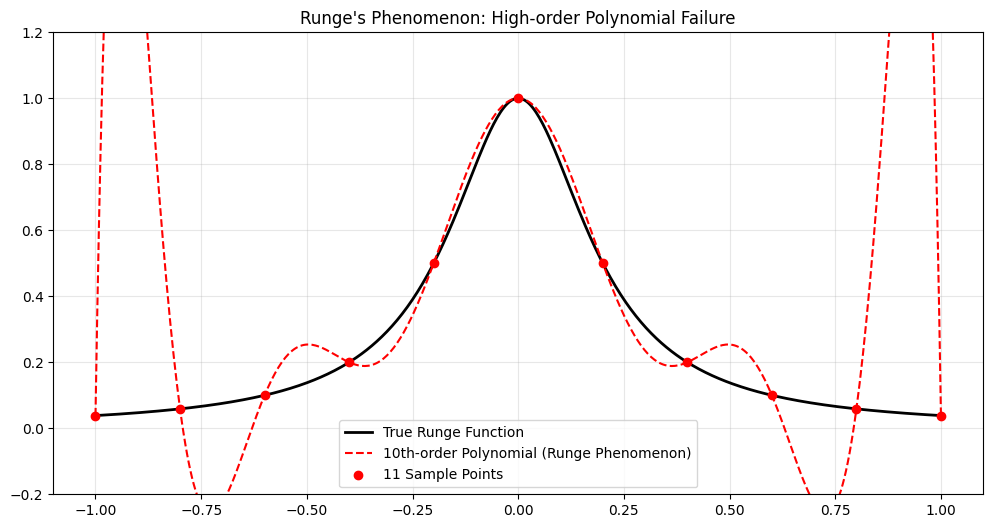

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, BarycentricInterpolator

# 1. 定义龙格函数 (Runge Function)
def runge_func(x):
    return 1 / (1 + 25 * x**2)

# 2. 设置插值区间
x_range = np.linspace(-1, 1, 500)
y_true = runge_func(x_range)

# 3. 生成等距采样点 (分别取 6 个点和 11 个点)
# 11 个点意味着会生成一个 10 次多项式，这足以触发明显的龙格现象
x_nodes = np.linspace(-1, 1, 11)
y_nodes = runge_func(x_nodes)

# 4. 执行插值
# 线性插值（作为对比）
f_linear = interp1d(x_nodes, y_nodes, kind='linear')
# 高次多项式插值 (使用重心拉格朗日插值法，防止计算不稳定)
f_high_poly = BarycentricInterpolator(x_nodes, y_nodes)

# 5. 绘图
plt.figure(figsize=(12, 6))
plt.plot(x_range, y_true, 'k-', lw=2, label='True Runge Function')
plt.plot(x_range, f_high_poly(x_range), 'r--', label='10th-order Polynomial (Runge Phenomenon)')
plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='11 Sample Points')

plt.ylim(-0.2, 1.2) # 限制 Y 轴范围以观察震荡
plt.title("Runge's Phenomenon: High-order Polynomial Failure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()